<a href="https://colab.research.google.com/github/weronikadomczewska/MCS-TimePoint-DTW/blob/main/timepoint/timepoint_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [118]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Training on synthetic data

In [119]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [120]:
import torch


def _patched_solve(B, A):
    return torch.linalg.solve(A, B), None


torch.solve = _patched_solve

from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt

In [121]:
SIGNAL_TO_TRAIN = "abp"  # or "abp"
SIGNAL_GENERATION_METHOD = 'mader' # or "lognormal"

PATHS_MAPPING = {
    "mader": "/content/drive/MyDrive/dataset_synthetic_cpab/mader",
    "lognormal": "/content/drive/MyDrive/dataset_synthetic_cpab/lognormal",
}

In [122]:
def collate_fn(batch):
    return {
        "x": torch.stack([b["x"] for b in batch]),
        "x_w": torch.stack([b["x_w"] for b in batch]),
        "kp": torch.stack([b["kp"] for b in batch]),
        "kp_w": torch.stack([b["kp_w"] for b in batch]),
        "match_mask": torch.stack([b["match_mask"] for b in batch]),
    }

In [123]:
import torch
import numpy as np
import os


# def random_crop(signal, window):
#     L = len(signal)

#     if L <= window:
#         return signal, 0  # start=0

#     start = np.random.randint(0, L - window)
#     return signal[start : start + window], start


def kp_to_mask(kp_indices, length):
    mask = np.zeros(length, dtype=np.float32)
    kp_indices = kp_indices[(kp_indices >= 0) & (kp_indices < length)]
    mask[kp_indices] = 1.0
    return mask


def process_signal(x, x_w, kp, kp_w, window):
    # crop
    # x, start = random_crop(x, window)
    # x_w = x_w[start : start + window]
    start = 0

    x = x[:window]
    x_w = x_w[:window]

    kp = kp[(kp >= start) & (kp < start + window)] - start
    kp_w = kp_w[(kp_w >= start) & (kp_w < start + window)] - start

    kp_mask = kp_to_mask(kp, window)
    kp_w_mask = kp_to_mask(kp_w, window)

    return x, x_w, kp_mask, kp_w_mask


class NPZLoader(torch.utils.data.Dataset):
    def __init__(self, data_dir, use_signal="abp", window=1024):
        self.files = [os.path.join(data_dir, f) for f in os.listdir(data_dir) if f.endswith(".npz")]
        self.use_signal = use_signal
        self.window = window

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        data = np.load(self.files[idx])

        if self.use_signal == "abp":
            x = data["abp"]
            x_w = data["abp_warped"]
            kp = data["abp_kp"]
            kp_w = data["abp_kp_warped"]

        else:
            x = data["cbfv"]
            x_w = data["cbfv_warped"]
            kp = data["cbfv_kp"]
            kp_w = data["cbfv_kp_warped"]

        x, x_w, kp_mask, kp_w_mask = process_signal(x, x_w, kp, kp_w, self.window)

        match_mask = np.outer(kp_mask, kp_w_mask).astype(np.float32)

        return {
            "x": torch.tensor(x, dtype=torch.float32),
            "x_w": torch.tensor(x_w, dtype=torch.float32),
            "kp": torch.tensor(kp_mask),
            "kp_w": torch.tensor(kp_w_mask),
            "match_mask": torch.tensor(match_mask, dtype=torch.float32),
        }


In [124]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

device: cuda


In [125]:
from torch.utils.data import Subset

# original dataset
dataset = NPZLoader(
    PATHS_MAPPING[SIGNAL_GENERATION_METHOD],
    use_signal=SIGNAL_TO_TRAIN
)

# choose subset size
subset_size = 1000

# first N samples
subset_indices = list(range(subset_size))

dataset = Subset(
    dataset,
    subset_indices
)

loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True,
    collate_fn=collate_fn
)

In [126]:
batch = next(iter(loader))

x = batch["x"].unsqueeze(1)       # [B,1,L]
x_w = batch["x_w"].unsqueeze(1)

kp = batch["kp"]                  # [B,L]
kp_w = batch["kp_w"]
match_mask = batch["match_mask"]  # [B,L,L]

In [127]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class KeypointDecoder(nn.Module):
    """
    Detector Head for predicting keypoint logits.
    """

    def __init__(self, input_channels, cell_size=8):

        super().__init__()

        self.cell_size = cell_size

        self.conv = nn.Conv1d(
            input_channels,
            cell_size + 1,
            kernel_size=1
        )

    def forward(self, x):

        # x: [N, C, L/8]

        N, C, Lc = x.shape

        # ==========================================
        # raw logits
        # ==========================================

        x = self.conv(x)

        # ==========================================
        # remove dustbin
        # ==========================================

        x = x[:, :-1, :]

        # ==========================================
        # reshape to [N,1,L]
        # ==========================================

        x = x.permute(0, 2, 1).reshape(

            N,
            1,
            Lc * self.cell_size
        )

        return x


class DescriptorDecoder(nn.Module):
    """
    Descriptor Head for generating feature descriptors.
    """

    def __init__(self, input_channels, descriptor_dim=256):
        super().__init__()
        self.conv = nn.Conv1d(input_channels, descriptor_dim, kernel_size=1)
        self.upsample = nn.Upsample(scale_factor=8, mode="linear", align_corners=False)

    def forward(self, x):
        # x: [N, C, L/8]
        x = self.conv(x)  # [N, descriptor_dim, L/8]
        x = self.upsample(x)  # [N, descriptor_dim, L]
        # x = F.normalize(x, p=2, dim=1)  # L2 norm along channel dimension, now performed at loss.
        return x

In [128]:
# https://github.com/BGU-CS-VIL/TimePoint/blob/main/TimePoint/models/wtconv1d.py

import torch
import torch.nn as nn
import torch.nn.functional as F

from functools import partial

import pywt
# from .util import wavelet


def create_wavelet_filter(wave, in_size, out_size, type=torch.float):
    w = pywt.Wavelet(wave)
    dec_hi = torch.tensor(w.dec_hi[::-1], dtype=type)
    dec_lo = torch.tensor(w.dec_lo[::-1], dtype=type)
    dec_filters = torch.stack([dec_lo, dec_hi], dim=0)

    dec_filters = dec_filters[:, None].repeat(in_size, 1, 1)

    rec_hi = torch.tensor(w.rec_hi[::-1], dtype=type).flip(dims=[0])
    rec_lo = torch.tensor(w.rec_lo[::-1], dtype=type).flip(dims=[0])
    rec_filters = torch.stack([rec_lo, rec_hi], dim=0)

    rec_filters = rec_filters[:, None].repeat(out_size, 1, 1)

    return dec_filters, rec_filters


def wavelet_transform(x, filters):
    b, c, l = x.shape
    pad = filters.shape[2] // 2 - 1
    x = F.conv1d(x, filters, stride=2, groups=c, padding=pad)
    x = x.reshape(b, c, 2, l // 2)
    return x


def inverse_wavelet_transform(x, filters):
    b, c, _, l_half = x.shape
    pad = filters.shape[2] // 2 - 1
    x = x.reshape(b, c * 2, l_half)
    x = F.conv_transpose1d(x, filters, stride=2, groups=c, padding=pad)
    return x


class WTConv1d(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size=5,
        stride=1,
        bias=True,
        wt_levels=1,
        wt_type="db1",
    ):
        super(WTConv1d, self).__init__()

        assert in_channels == out_channels

        self.in_channels = in_channels
        self.wt_levels = wt_levels
        self.stride = stride
        self.dilation = 1

        self.wt_filter, self.iwt_filter = create_wavelet_filter(
            wt_type, in_channels, in_channels, torch.float
        )
        self.wt_filter = nn.Parameter(self.wt_filter, requires_grad=False)
        self.iwt_filter = nn.Parameter(self.iwt_filter, requires_grad=False)

        self.wt_function = partial(wavelet_transform, filters=self.wt_filter)
        self.iwt_function = partial(inverse_wavelet_transform, filters=self.iwt_filter)

        self.base_conv = nn.Conv1d(
            in_channels,
            in_channels,
            kernel_size,
            padding="same",
            stride=1,
            dilation=1,
            groups=in_channels,
            bias=bias,
        )
        self.base_scale = _ScaleModule([1, in_channels, 1])

        self.wavelet_convs = nn.ModuleList(
            [
                nn.Conv1d(
                    in_channels * 2,
                    in_channels * 2,
                    kernel_size,
                    padding="same",
                    stride=1,
                    dilation=1,
                    groups=in_channels * 2,
                    bias=False,
                )
                for _ in range(self.wt_levels)
            ]
        )
        self.wavelet_scale = nn.ModuleList(
            [
                _ScaleModule([1, in_channels * 2, 1], init_scale=0.1)
                for _ in range(self.wt_levels)
            ]
        )

        if self.stride > 1:
            self.stride_filter = nn.Parameter(
                torch.ones(in_channels, 1, 1), requires_grad=False
            )
            self.do_stride = lambda x_in: F.conv1d(
                x_in,
                self.stride_filter,
                bias=None,
                stride=self.stride,
                groups=in_channels,
            )
        else:
            self.do_stride = None

    def forward(self, x):
        x_ll_in_levels = []
        x_h_in_levels = []
        shapes_in_levels = []

        curr_x_ll = x

        for i in range(self.wt_levels):
            curr_shape = curr_x_ll.shape
            shapes_in_levels.append(curr_shape)
            if curr_shape[2] % 2 > 0:
                curr_pads = (0, curr_shape[2] % 2)
                curr_x_ll = F.pad(curr_x_ll, curr_pads)

            curr_x = self.wt_function(curr_x_ll)
            curr_x_ll = curr_x[:, :, 0, :]

            shape_x = curr_x.shape
            curr_x_tag = curr_x.reshape(shape_x[0], shape_x[1] * 2, shape_x[3])
            curr_x_tag = self.wavelet_scale[i](self.wavelet_convs[i](curr_x_tag))
            curr_x_tag = curr_x_tag.reshape(shape_x)

            x_ll_in_levels.append(curr_x_tag[:, :, 0, :])
            x_h_in_levels.append(curr_x_tag[:, :, 1:2, :])

        next_x_ll = 0

        for i in range(self.wt_levels - 1, -1, -1):
            curr_x_ll = x_ll_in_levels.pop()
            curr_x_h = x_h_in_levels.pop()
            curr_shape = shapes_in_levels.pop()

            curr_x_ll = curr_x_ll + next_x_ll

            curr_x = torch.cat([curr_x_ll.unsqueeze(2), curr_x_h], dim=2)
            next_x_ll = self.iwt_function(curr_x)

            next_x_ll = next_x_ll[:, :, : curr_shape[2]]

        x_tag = next_x_ll
        assert len(x_ll_in_levels) == 0

        x = self.base_scale(self.base_conv(x))
        x = x + x_tag

        if self.do_stride is not None:
            x = self.do_stride(x)

        return x


class _ScaleModule(nn.Module):
    def __init__(self, dims, init_scale=1.0, init_bias=0):
        super(_ScaleModule, self).__init__()
        self.dims = dims
        self.weight = nn.Parameter(torch.ones(*dims) * init_scale)
        self.bias = None

    def forward(self, x):
        return torch.mul(self.weight, x)


In [129]:
import torch.nn as nn

# https://github.com/BGU-CS-VIL/TimePoint/blob/main/TimePoint/models/layers.py


class ConvBlock1D(nn.Module):
    def __init__(
        self,
        c_in,
        c_out,
        kernel_size=3,
        stride=1,
        norm=nn.BatchNorm1d,
        act=nn.ReLU,
        padding=1,
    ):
        super(ConvBlock1D, self).__init__()
        self.layer = nn.Sequential(
            nn.Conv1d(
                c_in, c_out, kernel_size=kernel_size, stride=stride, padding=padding
            ),
            norm(c_out),
            act(inplace=True),
        )

    def forward(self, x):
        return self.layer(x)


class WTConvBlock1D(nn.Module):
    def __init__(
        self,
        c_in,
        c_out,
        kernel_size=3,
        stride=1,
        norm=nn.BatchNorm1d,
        act=nn.ReLU,
        wt_levels=3,
    ):
        super(WTConvBlock1D, self).__init__()
        self.layer = nn.Sequential(
            WTConv1d(
                c_in, c_in, kernel_size=kernel_size, wt_levels=wt_levels, stride=stride
            ),
            nn.Conv1d(c_in, c_out, kernel_size=1, stride=1, padding=0),
            norm(c_out),
            act(),
        )

    def forward(self, x):
        return self.layer(x)


In [130]:
# import torch
import torch.nn as nn

# https://github.com/BGU-CS-VIL/TimePoint/blob/main/TimePoint/models/wtconv1d.py


class SharedEncoder(nn.Module):
    def __init__(
        self, input_channels=1, dims=[64, 64, 128, 128], stride=2, wt_levels=[3, 3, 3]
    ):
        super().__init__()
        self.stride = stride
        self.layer1 = ConvBlock1D(input_channels, dims[0], stride=1, padding="same")
        self.layer2 = WTConvBlock1D(
            dims[0], dims[1], stride=self.stride, wt_levels=wt_levels[0]
        )  # stride=2 to downsample
        self.layer3 = WTConvBlock1D(
            dims[1], dims[2], stride=self.stride, wt_levels=wt_levels[1]
        )
        self.layer4 = WTConvBlock1D(
            dims[2], dims[3], stride=self.stride, wt_levels=wt_levels[2]
        )

    def forward(self, x):
        # Input x: [N, C, L]
        x = self.layer1(x)  # [N, base_channels, L]
        x = self.layer2(x)  # [N, base_channels, L/2]
        x = self.layer3(x)  # [N, base_channels*2, L/4]
        x = self.layer4(x)  # [N, base_channels*2, L/8]
        return x  # Feature map of size L/8

In [131]:
import torch
import torch.nn.functional as F
import numpy as np

def get_topk_in_original_order(X_desc, X_probas, K):
    """
    Get the descriptors of the top K keypoints from X_probas without changing their original order.

    Args:
        X_desc (torch.Tensor): The descriptors associated with keypoints, shape [N, C, L].
        X_probas (torch.Tensor): Tensor of keypoint probabilities, shape [N, L].
        K (int): Number of top elements to select per sample.

    Returns:
        X_topk (torch.Tensor): Tensor containing the descriptors of the top K keypoints per sample, shape [N, C, K].
    """
    N, C, L = X_desc.shape
    assert X_probas.shape == (N, L), "X_keypoints must have shape (N, L)"

    device = X_probas.device
    if K >= L:
        # If K is greater than or equal to L, return all points in original order
        # In this case, X_probas are the keypoint probabilities, and X_desc are the descriptors
        # We need to return sorted_topk_indices and X_topk in a consistent way.
        # If all points are kept, indices are just 0 to L-1
        sorted_topk_indices = torch.arange(L, device=device).unsqueeze(0).repeat(N, 1)
        return sorted_topk_indices, X_desc

    # Get the indices of the top K values per sample
    topk_values, topk_indices = torch.topk(X_probas, K, dim=1)
    # topk_indices: shape [N, K]

    # Sort the indices per sample to maintain original order
    sorted_topk_indices, _ = torch.sort(topk_indices, dim=1)
    # sorted_topk_indices: shape [N, K]

    # Expand indices for gathering
    indices_expanded = sorted_topk_indices.unsqueeze(1).expand(-1, C, -1)  # Shape: [N, C, K]

    # Gather descriptors along the L dimension (time steps)
    X_topk = torch.gather(X_desc, dim=2, index=indices_expanded)  # Shape: [N, C, K]

    return sorted_topk_indices, X_topk


def non_maximum_suppression(detection_prob, window_size=7):
    """
    Apply non-maximum suppression to the detection map.

    Args:
        detection_map: Tensor of shape [N, L].
        window_size: Size of the window for NMS.

    Returns:
        keypoints: Tensor of shape [N, L], boolean mask of keypoints after NMS.
    """
    if isinstance(detection_prob, np.ndarray):
        detection_prob = torch.from_numpy(detection_prob)

    N, L = detection_prob.shape

    # F.max_pool1d expects input of shape (N, C, L_in). Here C=1.
    detection_prob_3d = detection_prob.unsqueeze(1) # Shape becomes [N, 1, L]

    pooled, pooled_idx = F.max_pool1d(detection_prob_3d, kernel_size=window_size,
                                      stride=window_size, padding=window_size // 2,
                                      return_indices=True)

    # pooled_idx shape: [N, 1, L_pooled]. Squeeze the channel dimension.
    pooled_idx = pooled_idx.squeeze(1) # Shape [N, L_pooled]

    # Create a mask to zero out non-maximum values
    mask = torch.zeros_like(detection_prob, dtype=torch.bool)

    for i in range(N):
        # For each batch item, set True only at the indices that were maximum in their window
        mask[i, pooled_idx[i]] = True

    # Apply the mask to the original detection probabilities
    detection_prob_nms = detection_prob * mask.float()

    return detection_prob_nms

In [132]:
import torch.nn as nn
import torch


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


class TimePointModel(nn.Module):
    def __init__(
        self, input_channels=1, encoder_dims=[64, 64, 128, 128], descriptor_dim=256
    ):
        super().__init__()

        self.encoder = SharedEncoder(input_channels, encoder_dims)

        encoder_output_channels = encoder_dims[-1]

        self.detector_head = KeypointDecoder(encoder_output_channels)
        self.descriptor_head = DescriptorDecoder(
            encoder_output_channels, descriptor_dim
        )

    def forward(self, x):
        N, C, L = x.shape

        features = self.encoder(x)

        # --- Keypoints ---
        S_scores = self.detector_head(features)  # [B,1,L]
        S_scores = S_scores[:, :, :L]
        S_scores = S_scores.squeeze(1)  # [B,L]

        # --- Descriptors ---
        D = self.descriptor_head(features)  # [B,D,L]
        D = D[:, :, :L]
        D = D.permute(0, 2, 1)  # [B,L,D]

        return S_scores, D

    def get_topk_points(self, x, kp_percent=1, nms_window=5):
        N, C, L = x.shape

        features = self.encoder(x)

        detection_proba = self.detector_head(features)[:, :, :L]
        descriptors = self.descriptor_head(features)[:, :, :L]

        detection_proba = detection_proba.squeeze(1)

        detection_proba = non_maximum_suppression(
            detection_proba, window_size=nms_window
        )

        if kp_percent < 1:
            num_kp = int(kp_percent * L)

            sorted_topk_indices, detection_proba = get_topk_in_original_order(
                detection_proba, detection_proba, K=num_kp
            )
        else:
            sorted_topk_indices = torch.arange(L)

        return sorted_topk_indices, detection_proba, descriptors

In [133]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# https://github.com/BGU-CS-VIL/TimePoint/blob/main/TimePoint/models/wtconv1d.py

# class TimePointKeypointLoss(nn.Module):

#     def __init__(self, pos_weight=80.0):
#         super().__init__()

#         self.pos_weight = pos_weight

#     def forward(self, S_probs, Y_true):

#         Y_true = Y_true.float()

#         pos_weight = torch.tensor(
#             self.pos_weight,
#             device=S_probs.device
#         )

#         loss_fn = nn.BCEWithLogitsLoss(
#             pos_weight=pos_weight
#         )

#         loss = loss_fn(
#             S_probs,
#             Y_true
#         )

#         return loss


class TimePointKeypointLoss(nn.Module):

    def __init__(self, pos_weight=80.0):

        super().__init__()

        self.pos_weight = pos_weight

    def forward(self, S_logits, Y_true):

        Y_true = Y_true.float()

        pos_weight = torch.tensor(

            self.pos_weight,

            device=S_logits.device
        )

        loss_fn = nn.BCEWithLogitsLoss(

            pos_weight=pos_weight
        )

        loss = loss_fn(

            S_logits,

            Y_true
        )

        return loss


class TimePointDescriptorLoss(nn.Module):
    def __init__(self, mp=1.0, mn=0.1):
        """
        mp: positive margin (target similarity)
        mn: negative margin (maximum allowed similarity)
        """
        super().__init__()
        self.mp = mp
        self.mn = mn

    def forward(self, D, D_prime, match_mask):
        """
        D:         [B, N, D]  - descriptors (original)
        D_prime:   [B, N, D]  - descriptors (warped)
        match_mask:[B, N, N]  - 1 if (i,j) is matching pair

        returns: scalar loss
        """

        # normalize descriptors
        D = F.normalize(D, p=2, dim=-1)
        D_prime = F.normalize(D_prime, p=2, dim=-1)

        # cosine similarity matrix
        # shape: [B, N, N]
        sim = torch.bmm(D, D_prime.transpose(1, 2))

        # positive loss
        pos_loss = match_mask * (F.relu(self.mp - sim) ** 2)

        # negative loss
        neg_mask = 1.0 - match_mask
        neg_loss = neg_mask * (F.relu(sim - self.mn) ** 2)

        # combine
        loss = pos_loss + neg_loss

        return loss.mean()

In [134]:
class TimePointOverallLoss(nn.Module):
    def __init__(self, mp=1.0, mn=0.1, lambda_desc=1.0):
        super().__init__()

        self.kp_loss_fn = TimePointKeypointLoss()
        self.desc_loss_fn = TimePointDescriptorLoss(mp=mp, mn=mn)

        self.lambda_desc = lambda_desc

    def forward(
        self,
        S_logits,
        Y_true,
        S_prime_logits,
        Y_prime_true,
        D,
        D_prime,
        match_mask,
    ):
        # Keypoint losses (with sigmoid inside)
        loss_kp_orig = self.kp_loss_fn(S_logits, Y_true)
        loss_kp_warped = self.kp_loss_fn(S_prime_logits, Y_prime_true)

        # Descriptor loss
        loss_desc = self.desc_loss_fn(D, D_prime, match_mask)

        # Total loss
        total_loss = loss_kp_orig + loss_kp_warped + self.lambda_desc * loss_desc

        return total_loss, {
            "total": total_loss.item(),
            "kp_orig": loss_kp_orig.item(),
            "kp_warped": loss_kp_warped.item(),
            "desc": loss_desc.item(),
        }

In [135]:
model = TimePointModel()
model = model.to(device)

criterion = TimePointOverallLoss(
    mp=1.0,
    mn=0.1,
    lambda_desc=1.0
)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [136]:
S, D = model(x.to(device))
S_w, D_w = model(x_w.to(device))

print("S:", S.shape)
print("D:", D.shape)
print("match_mask:", match_mask.shape)

S: torch.Size([8, 1024])
D: torch.Size([8, 1024, 256])
match_mask: torch.Size([8, 1024, 1024])


In [137]:
import os

save_dir = f"/content/drive/MyDrive/timepoint_weights_{SIGNAL_TO_TRAIN}_{SIGNAL_GENERATION_METHOD}"
os.makedirs(save_dir, exist_ok=True)

In [139]:
from tqdm.auto import tqdm

epochs = 50

loss_history = []

for epoch in range(epochs):

    print(f"\nEpoch {epoch}")

    model.train()

    epoch_loss_dict = {

        "total": 0.0,
        "kp_orig": 0.0,
        "kp_warped": 0.0,
        "desc": 0.0,
    }

    total_loss = 0.0

    for batch in tqdm(loader, desc=f"Epoch {epoch}"):

        # ==========================================
        # data
        # ==========================================

        x = batch["x"].float().to(device).unsqueeze(1)

        x_w = batch["x_w"].float().to(device).unsqueeze(1)

        kp = batch["kp"].float().to(device)

        kp_w = batch["kp_w"].float().to(device)

        match_mask = batch["match_mask"].float().to(device)

        # ==========================================
        # forward
        # ==========================================

        S_logits, D = model(x)

        S_w_logits, D_w = model(x_w)

        # ==========================================
        # loss
        # ==========================================

        loss, loss_dict = criterion(

            S_logits,
            kp,

            S_w_logits,
            kp_w,

            D,
            D_w,

            match_mask
        )

        # ==========================================
        # backward
        # ==========================================

        optimizer.zero_grad()

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        # ==========================================
        # accumulate losses
        # ==========================================

        total_loss += loss.item()

        for key in epoch_loss_dict:

            epoch_loss_dict[key] += loss_dict[key]

    # ==============================================
    # average losses
    # ==============================================

    num_batches = len(loader)

    for key in epoch_loss_dict:

        epoch_loss_dict[key] /= num_batches

    # ==============================================
    # store
    # ==============================================

    loss_history.append(
        epoch_loss_dict
    )

    # ==============================================
    # print
    # ==============================================

    print(epoch_loss_dict)

    # ==============================================
    # save checkpoints
    # ==============================================


    save_path = os.path.join(

        save_dir,

        f"model_epoch_{epoch}.pth"
    )

    torch.save({

        "epoch": epoch,

        "model_state_dict": model.state_dict(),

        "optimizer_state_dict": optimizer.state_dict(),

        "loss": epoch_loss_dict["total"],

    }, save_path)


Epoch 0


Epoch 0:   0%|          | 0/125 [00:00<?, ?it/s]

{'total': 2.007873805999756, 'kp_orig': 0.5976218881607056, 'kp_warped': 1.403010416984558, 'desc': 0.007241502281278372}

Epoch 1


Epoch 1:   0%|          | 0/125 [00:00<?, ?it/s]

{'total': 2.0212197980880737, 'kp_orig': 0.6082904448509217, 'kp_warped': 1.4053121271133422, 'desc': 0.0076172310747206215}

Epoch 2


...

{'total': 1.834044813156128, 'kp_orig': 0.48928758382797244, 'kp_warped': 1.3393792419433594, 'desc': 0.005377990497276187}

Epoch 48


Epoch 48:   0%|          | 0/125 [00:00<?, ?it/s]

{'total': 1.8402545957565308, 'kp_orig': 0.5026572325229645, 'kp_warped': 1.3317340927124024, 'desc': 0.005863268122076988}

Epoch 49


Epoch 49:   0%|          | 0/125 [00:00<?, ?it/s]

{'total': 1.8270033521652222, 'kp_orig': 0.4997358102798462, 'kp_warped': 1.3219805631637573, 'desc': 0.0052869803868234155}


In [140]:
def visualize(sample, model):
    model.eval()

    x = sample["x"].unsqueeze(0).unsqueeze(0).to(device)
    x_w = sample["x_w"].unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():
        S_logits, _ = model(x)
        S_w_logits, _ = model(x_w)

    S = torch.sigmoid(S_logits).cpu().numpy()[0]
    S_w = torch.sigmoid(S_w_logits).cpu().numpy()[0]

    t = np.arange(len(S))

    plt.figure(figsize=(12,5))
    plt.plot(t, sample["x"], label=SIGNAL_TO_TRAIN.upper())
    plt.plot(t, sample["x_w"], label="Warped", alpha=0.7)

    plt.scatter(t[S > 0.5], sample["x"][S > 0.5], color="red", label="KP")
    plt.scatter(t[S_w > 0.5], sample["x_w"][S_w > 0.5], color="blue", label="KP warped")

    plt.legend()
    plt.title("Predicted keypoints")
    plt.show()

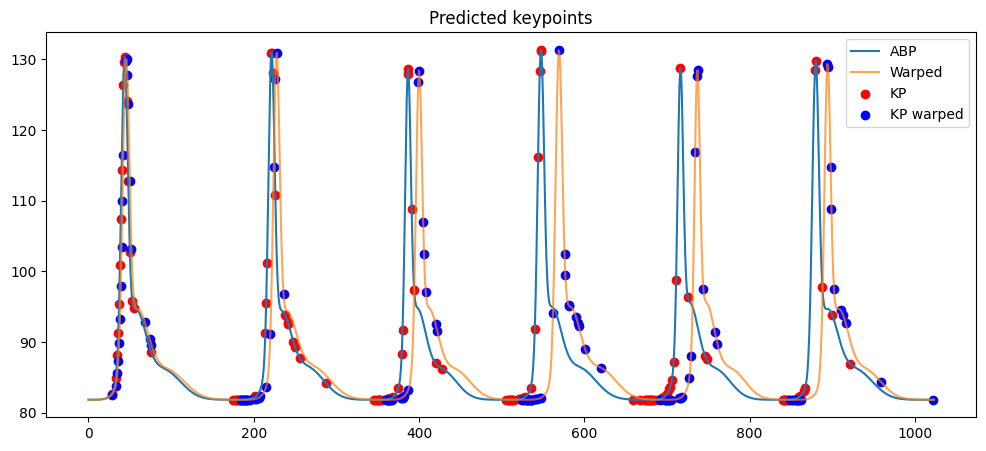

In [141]:
sample = dataset[0]
visualize(sample, model)

### Training Loss Evolution

Let's visualize the training loss over the epochs to observe the model's learning progress.

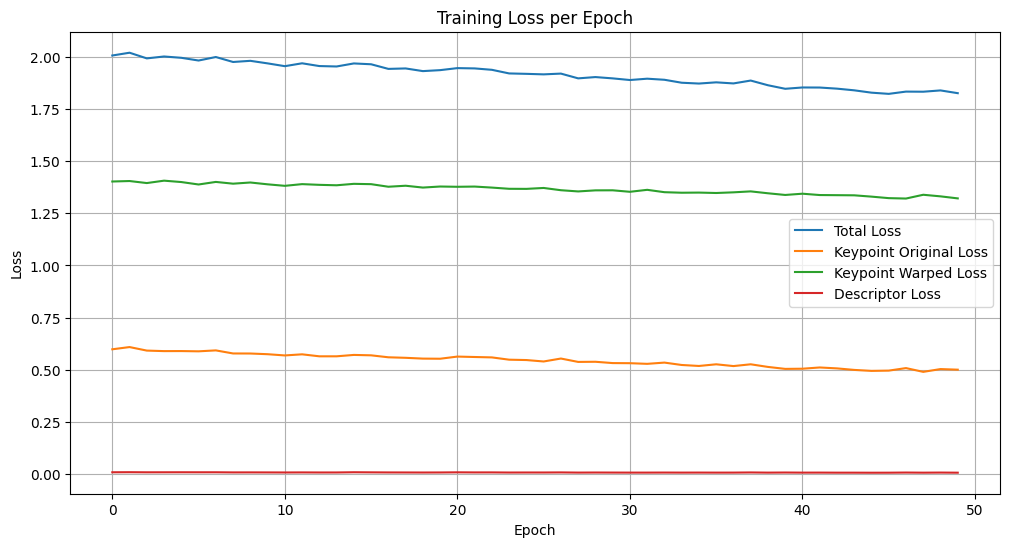

In [142]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert loss_history to a DataFrame for easier plotting
loss_df = pd.DataFrame(loss_history)

plt.figure(figsize=(12, 6))
plt.plot(loss_df.index, loss_df['total'], label='Total Loss')
plt.plot(loss_df.index, loss_df['kp_orig'], label='Keypoint Original Loss')
plt.plot(loss_df.index, loss_df['kp_warped'], label='Keypoint Warped Loss')
plt.plot(loss_df.index, loss_df['desc'], label='Descriptor Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss per Epoch')
plt.legend()
plt.grid(True)
plt.show()

# Fine-tuning on real data

In [143]:
model = TimePointModel().to(device)

checkpoint = torch.load(f"{save_dir}/model_epoch_10.pth", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])

<All keys matched successfully>

Encoder freezing

In [144]:
for param in model.encoder.parameters():
    param.requires_grad = False

In [145]:
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

Adding both baseline and position change data

In [146]:

from torch.utils.data import ConcatDataset

baseline_dataset = NPZLoader(
    "/content/drive/MyDrive/data_for_finetuning/baseline",
    use_signal=SIGNAL_TO_TRAIN,
    window=1024,
)

position_dataset = NPZLoader(
    "/content/drive/MyDrive/data_for_finetuning/position",
    use_signal=SIGNAL_TO_TRAIN,
    window=1024,
)

dataset = ConcatDataset([
    baseline_dataset,
    position_dataset,
])

In [147]:
print("Baseline:", len(baseline_dataset))
print("Position :", len(position_dataset))
print("Total    :", len(dataset))

Baseline: 47
Position : 48
Total    : 95


In [148]:
epochs = 25

# Re-initialize the loader with the new ConcatDataset
loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True,
    collate_fn=collate_fn
)

loss_history_finetune = [] # Initialize list to store fine-tuning loss history

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in loader:
        x = batch["x"].to(device).unsqueeze(1)     # [B,1,L]
        x_w = batch["x_w"].to(device).unsqueeze(1)

        kp = batch["kp"].to(device)
        kp_w = batch["kp_w"].to(device)

        match_mask = batch["match_mask"].to(device)

        # forward
        S_logits, D = model(x)
        S_w_logits, D_w = model(x_w)

        # loss
        loss, loss_dict = criterion(
            S_logits, kp,
            S_w_logits, kp_w,
            D, D_w,
            match_mask
        )

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    # Store loss_dict for the current epoch
    loss_history_finetune.append(loss_dict)

    print(f"\nEpoch {epoch}")
    print(f"Total loss: {total_loss:.4f}")
    print(loss_dict)

    # saving model weights
    save_path = os.path.join(f"{save_dir}_fine_tuned", f"model_epoch_{epoch}.pth")
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "loss": total_loss,
        },
        save_path,
    )



Epoch 0
Total loss: 36.1223
{'total': 2.930361032485962, 'kp_orig': 0.9308663010597229, 'kp_warped': 1.9897279739379883, 'desc': 0.009766768664121628}

Epoch 1
Total loss: 35.6940
{'total': 2.717247724533081, 'kp_orig': 0.8569099307060242, 'kp_warped': 1.8520132303237915, 'desc': 0.00832468643784523}

Epoch 2
Total loss: 35.3159
{'total': 2.8089277744293213, 'kp_orig': 0.9702659249305725, 'kp_warped': 1.8304129838943481, 'desc': 0.008248920552432537}

Epoch 3
Total loss: 34.9994
{'total': 2.819772243499756, 'kp_orig': 0.8968403935432434, 'kp_warped': 1.9151780605316162, 'desc': 0.007753738667815924}

Epoch 4
Total loss: 34.4478
{'total': 2.7059621810913086, 'kp_orig': 0.8580281138420105, 'kp_warped': 1.8403476476669312, 'desc': 0.007586359977722168}

Epoch 5
Total loss: 34.4390
{'total': 2.977886438369751, 'kp_orig': 0.8874590992927551, 'kp_warped': 2.0823352336883545, 'desc': 0.008092171512544155}

Epoch 6
Total loss: 34.0655
{'total': 2.727649450302124, 'kp_orig': 0.8435238599777222

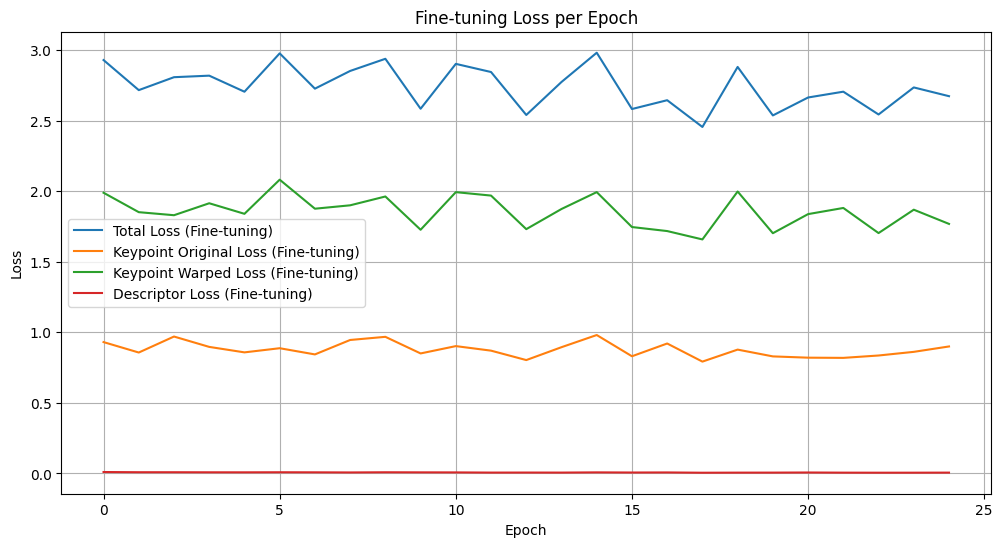

In [150]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert loss_history_finetune to a DataFrame for easier plotting
loss_df_finetune = pd.DataFrame(loss_history_finetune)

plt.figure(figsize=(12, 6))
plt.plot(loss_df_finetune.index, loss_df_finetune['total'], label='Total Loss (Fine-tuning)')
plt.plot(loss_df_finetune.index, loss_df_finetune['kp_orig'], label='Keypoint Original Loss (Fine-tuning)')
plt.plot(loss_df_finetune.index, loss_df_finetune['kp_warped'], label='Keypoint Warped Loss (Fine-tuning)')
plt.plot(loss_df_finetune.index, loss_df_finetune['desc'], label='Descriptor Loss (Fine-tuning)')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Fine-tuning Loss per Epoch')
plt.legend()
plt.grid(True)
plt.show()

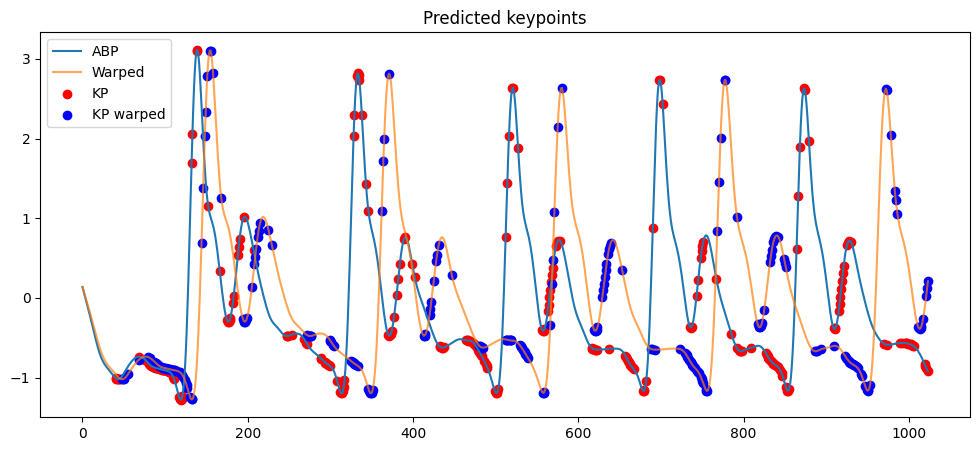

In [151]:
sample = dataset[0]
visualize(sample, model)

Visualizing keypoints BEFORE fine-tuning...


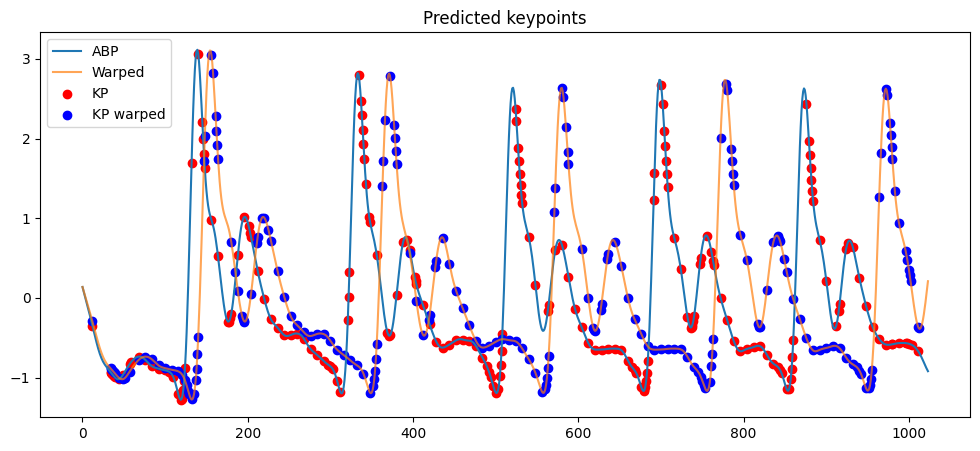

In [152]:
# Visualize keypoints before fine-tuning (using the checkpoint loaded in cell 15)
print("Visualizing keypoints BEFORE fine-tuning...")

# Create a new model instance to load the pre-fine-tuned weights
model_before_finetuning = TimePointModel().to(device)
checkpoint_before_finetuning = torch.load(f"{save_dir}/model_epoch_25.pth", map_location=device)
model_before_finetuning.load_state_dict(checkpoint_before_finetuning["model_state_dict"])
model_before_finetuning.eval()

# Use the same sample as before
sample_to_visualize = dataset[0] # Use the first sample from the fine-tuning dataset
visualize(sample_to_visualize, model_before_finetuning)


Visualizing keypoints AFTER fine-tuning...


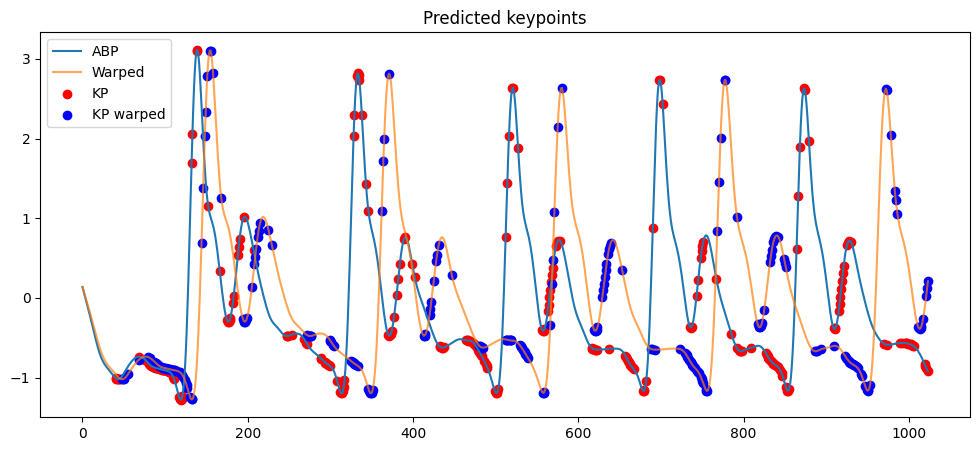

In [153]:
# Visualize keypoints AFTER fine-tuning (using the current 'model' instance)
print("Visualizing keypoints AFTER fine-tuning...")

# The 'model' variable already holds the fine-tuned model after cell 20's execution
model.eval()

# Use the same sample as before
sample_to_visualize = dataset[0] # Use the first sample from the fine-tuning dataset
visualize(sample_to_visualize, model)


Number of keypoints and number of epochs

In [154]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import os

In [157]:
checkpoints = [

    (10, f"{save_dir}/model_epoch_0.pth"),

    (25, f"{save_dir}/model_epoch_24.pth"),

    (50, f"{save_dir}/model_epoch_49.pth")
]

In [158]:
@torch.no_grad()
def extract_sparse_representation(
    signal,
    model,
    device,
    threshold=0.3,
    nms_window=15,
):

    # ==========================================
    # normalize
    # ==========================================

    signal = normalize_signal(signal)

    x = torch.tensor(
        signal,
        dtype=torch.float32
    ).unsqueeze(0).unsqueeze(0).to(device)

    # ==========================================
    # forward
    # ==========================================

    S_logits, D = model(x)

    # logits -> probabilities
    S_probs = torch.sigmoid(S_logits)

    # [B,L]
    if S_probs.ndim == 3:
        S_probs = S_probs.squeeze(1)

    # ==========================================
    # NMS
    # ==========================================

    S_nms = non_maximum_suppression(

        S_probs.clone(),

        window_size=nms_window
    )

    # ==========================================
    # thresholding
    # ==========================================

    kp_idx = torch.where(

        S_nms.squeeze(0) > threshold

    )[0]

    # ==========================================
    # descriptors
    # ==========================================

    # D: [B,L,D]
    # -> [B,D,L]
    D_for_gather = D.permute(0, 2, 1)

    # select descriptors at kp positions
    desc_topk = D_for_gather[
        0,
        :,
        kp_idx
    ]

    # ==========================================
    # numpy conversion
    # ==========================================

    kp_idx = kp_idx.cpu().numpy()

    desc_topk = (
        desc_topk
        .T
        .cpu()
        .numpy()
    )

    probs = (
        S_probs
        .squeeze(0)
        .cpu()
        .numpy()
    )

    return kp_idx, desc_topk, probs

In [159]:
def count_keypoints_for_model(

    checkpoint_path,
    dataset_paths,
    model_class,
    device,
):

    # ============================================
    # load model
    # ============================================

    model = model_class().to(device)

    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    model.eval()

    # ============================================
    # stats
    # ============================================

    kp_counts = []

    # ============================================
    # iterate files
    # ============================================

    for path in dataset_paths:

        data = np.load(path)

        signal = data["cbfv"]

        # ========================================
        # sparse representation
        # ========================================

        kp_idx, desc, probs = (
            extract_sparse_representation(

                signal,

                model,

                device,


                nms_window=15,
            )
        )

        kp_counts.append(
            len(kp_idx)
        )

    return {

        "mean_kp": np.mean(kp_counts),

        "std_kp": np.std(kp_counts),

        "all_kp": kp_counts,
    }

In [160]:
baseline_dir = "/content/drive/MyDrive/data_for_finetuning/baseline"

position_dir = "/content/drive/MyDrive/data_for_finetuning/position"

In [161]:
baseline_files = [

    os.path.join(
        baseline_dir,
        f
    )

    for f in os.listdir(baseline_dir)

    if f.endswith(".npz")
]

position_files = [

    os.path.join(
        position_dir,
        f
    )

    for f in os.listdir(position_dir)

    if f.endswith(".npz")
]

all_files = baseline_files + position_files

In [162]:
results = []

for epochs, checkpoint_path in checkpoints:

    print("Evaluating:", epochs)

    stats = count_keypoints_for_model(

        checkpoint_path,

        all_files,

        TimePointModel,

        device,
    )

    results.append({

        "epochs": epochs,

        "mean_kp": stats["mean_kp"],

        "std_kp": stats["std_kp"],
    })

Evaluating: 10
Evaluating: 25
Evaluating: 50


In [163]:
kp_df = pd.DataFrame(results)

kp_df

,epochs,mean_kp,std_kp
0,10,4503.378947,2519.475531
1,25,4503.378947,2519.474775
2,50,4503.494737,2519.516035


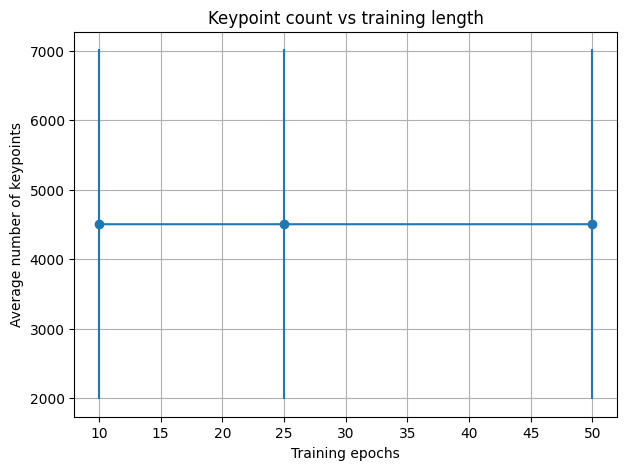

In [164]:
plt.figure(figsize=(7,5))

plt.errorbar(

    kp_df["epochs"],

    kp_df["mean_kp"],

    yerr=kp_df["std_kp"],

    marker="o",
)

plt.xlabel("Training epochs")

plt.ylabel("Average number of keypoints")

plt.title("Keypoint count vs training length")

plt.grid()

plt.show()

## DTW testing

In [165]:
%pip install fastdtw

In [166]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

from fastdtw import fastdtw
from scipy.spatial.distance import cosine, euclidean
from scipy.stats import zscore

In [168]:
epoch = "24"
save_path = os.path.join(f"{save_dir}_fine_tuned", f"model_epoch_{epoch}.pth")

In [169]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TimePointModel()

checkpoint = torch.load(
    save_path,
    map_location=device,
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.to(device)
model.eval()

TimePointModel(
  (encoder): SharedEncoder(
    (layer1): ConvBlock1D(
      (layer): Sequential(
        (0): Conv1d(1, 64, kernel_size=(3,), stride=(1,), padding=same)
        (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (layer2): WTConvBlock1D(
      (layer): Sequential(
        (0): WTConv1d(
          (base_conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=same, groups=64)
          (base_scale): _ScaleModule()
          (wavelet_convs): ModuleList(
            (0-2): 3 x Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=same, groups=128, bias=False)
          )
          (wavelet_scale): ModuleList(
            (0-2): 3 x _ScaleModule()
          )
        )
        (1): Conv1d(64, 64, kernel_size=(1,), stride=(1,))
        (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (3): ReLU()
      )
    )
    (layer3): WTConvBlock1D(
     

In [170]:
from scipy.stats import zscore

def normalize_signal(x):

    x = np.asarray(x)

    return zscore(x)

In [171]:
def add_noise(signal, noise_std=0.1):

    noise = np.random.normal(
        0,
        noise_std,
        size=len(signal),
    )

    return signal + noise

In [172]:
@torch.no_grad()
def extract_sparse_representation(
    signal,
    model,
    device,
    topk=20,
    nms_window=15,
):

    signal = normalize_signal(signal)

    x = torch.tensor(
        signal,
        dtype=torch.float32
    ).unsqueeze(0).unsqueeze(0).to(device)

    # forward
    S_probs, D = model(x) # D is [B, L_signal, D_dim]

    # [B,1,L] -> [B,L]
    if S_probs.ndim == 3:
        S_probs = S_probs.squeeze(1)

    # NMS
    S_nms = non_maximum_suppression(
        S_probs.clone(),
        window_size=nms_window,
    )

    # IMPORTANT:
    # get_topk_in_original_order expects X_desc to be [N, C, L_signal]
    # D from model(x) is [B, L_signal, D_dim], so permute to [B, D_dim, L_signal]
    D_for_topk = D.permute(0, 2, 1)

    kp_idx, desc_topk = get_topk_in_original_order(
        D_for_topk,
        S_nms,
        K=topk,
    )

    kp_idx = kp_idx.squeeze(0).cpu().numpy()

    desc_topk = (
        desc_topk
        .squeeze(0)
        .T
        .cpu()
        .numpy()
    )

    return kp_idx, desc_topk, S_probs.squeeze(0).cpu().numpy()

In [173]:
def sparse_descriptor_dtw(
    desc1,
    desc2,
):

    t0 = time.time()

    distance, path = fastdtw(
        desc1,
        desc2,
        dist=cosine,
    )

    runtime = time.time() - t0

    return distance, path, runtime

In [174]:
def full_signal_dtw(
    sig1,
    sig2,
):

    sig1 = normalize_signal(sig1)
    sig2 = normalize_signal(sig2)

    t0 = time.time()

    distance, path = fastdtw(
        sig1.reshape(-1, 1),
        sig2.reshape(-1, 1),
        dist=euclidean,
    )

    runtime = time.time() - t0

    return distance, path, runtime

In [175]:
def plot_keypoints(
    signal,
    kp_idx,
    title="",
):

    plt.figure(figsize=(14,4))

    plt.plot(signal)

    plt.scatter(
        kp_idx,
        signal[kp_idx],
        s=40,
    )

    plt.title(title)

    plt.grid()
    plt.show()

In [176]:
def plot_dtw_path(
    path,
    title="DTW path",
):

    path = np.array(path)

    plt.figure(figsize=(6,6))

    plt.plot(
        path[:,0],
        path[:,1],
    )

    plt.xlabel("Signal 1")
    plt.ylabel("Signal 2")

    plt.title(title)

    plt.grid()
    plt.show()

In [177]:
def analyze_recording(
    path,
    model,
    device,
    noise_std=0.1,
):

    data = np.load(path)

    abp = data["abp"]
    cbfv = data["cbfv"]

    # ========================================================
    # CLEAN SIGNALS
    # ========================================================

    kp_abp, desc_abp, _ = extract_sparse_representation(
        abp,
        model,
        device,
    )

    kp_cbfv, desc_cbfv, _ = extract_sparse_representation(
        cbfv,
        model,
        device,
    )

    # sparse DTW
    sparse_cost_clean, sparse_path, sparse_runtime = (
        sparse_descriptor_dtw(
            desc_abp,
            desc_cbfv,
        )
    )

    # full DTW
    full_cost_clean, full_path, full_runtime = (
        full_signal_dtw(
            abp,
            cbfv,
        )
    )

    # ========================================================
    # NOISY SIGNALS
    # ========================================================

    abp_noisy = add_noise(
        abp,
        noise_std=noise_std,
    )

    cbfv_noisy = add_noise(
        cbfv,
        noise_std=noise_std,
    )

    kp_abp_n, desc_abp_n, _ = extract_sparse_representation(
        abp_noisy,
        model,
        device,
    )

    kp_cbfv_n, desc_cbfv_n, _ = extract_sparse_representation(
        cbfv_noisy,
        model,
        device,
    )

    # sparse noisy
    sparse_cost_noisy, _, _ = sparse_descriptor_dtw(
        desc_abp_n,
        desc_cbfv_n,
    )

    # full noisy
    full_cost_noisy, _, _ = full_signal_dtw(
        abp_noisy,
        cbfv_noisy,
    )

    # ========================================================
    # ROBUSTNESS
    # ========================================================

    sparse_delta = abs(
        sparse_cost_noisy - sparse_cost_clean
    )

    full_delta = abs(
        full_cost_noisy - full_cost_clean
    )

    # ========================================================
    # RESULTS
    # ========================================================

    results = {

        # runtime
        "full_runtime": full_runtime,
        "sparse_runtime": sparse_runtime,

        # clean cost
        "full_cost_clean": full_cost_clean,
        "sparse_cost_clean": sparse_cost_clean,

        # noisy cost
        "full_cost_noisy": full_cost_noisy,
        "sparse_cost_noisy": sparse_cost_noisy,

        # robustness
        "full_delta": full_delta,
        "sparse_delta": sparse_delta,

        # keypoints
        "num_kp_abp": len(kp_abp),
        "num_kp_cbfv": len(kp_cbfv),
    }

    return results

In [178]:
def run_dataset_experiment(
    directory,
    label,
    model,
    device,
    exclude_files=None,
):
    if exclude_files is None:
        exclude_files = []

    all_results = []

    files = sorted(os.listdir(directory))

    for file in files:

        if not file.endswith(".npz"):
            continue

        if file in exclude_files:
            print(f"Skipping excluded file: {file}")
            continue

        path = os.path.join(directory, file)

        print("Processing:", file)

        result = analyze_recording(
            path,
            model,
            device,
        )

        result["condition"] = label
        result["file"] = file

        all_results.append(result)

    return all_results

In [179]:
baseline_dir = "/content/drive/MyDrive/data_for_finetuning/baseline"

position_dir = "/content/drive/MyDrive/data_for_finetuning/position"

In [76]:
from scipy.spatial.distance import euclidean

exclude_files = ["sample_PAC_02.npz", "sample_PAC_33.npz", "sample_PAC_38.npz", "sample_PAC_39.npz", "sample_PAC_02.npz", "sample_PAC_03.npz"]

baseline_results = run_dataset_experiment(
    baseline_dir,
    "baseline",
    model,
    device,
    exclude_files=exclude_files
)

Processing: sample_PAC_01.npz
Skipping excluded file: sample_PAC_02.npz
Skipping excluded file: sample_PAC_03.npz
Processing: sample_PAC_04.npz
Processing: sample_PAC_05.npz
Processing: sample_PAC_06.npz
Processing: sample_PAC_07.npz
Processing: sample_PAC_08.npz
Processing: sample_PAC_09.npz
Processing: sample_PAC_10.npz
Processing: sample_PAC_11.npz
Processing: sample_PAC_12.npz
Processing: sample_PAC_13.npz
Processing: sample_PAC_14.npz
Processing: sample_PAC_15.npz
Processing: sample_PAC_16.npz
Processing: sample_PAC_17.npz
Processing: sample_PAC_18.npz
Processing: sample_PAC_19.npz
Processing: sample_PAC_20.npz
Processing: sample_PAC_21.npz
Processing: sample_PAC_22.npz
Processing: sample_PAC_23.npz
Processing: sample_PAC_24.npz
Processing: sample_PAC_25.npz
Processing: sample_PAC_26.npz
Processing: sample_PAC_27.npz
Processing: sample_PAC_28.npz
Processing: sample_PAC_29.npz
Processing: sample_PAC_30.npz
Processing: sample_PAC_31.npz
Processing: sample_PAC_32.npz
Processing: samp

In [77]:
position_results = run_dataset_experiment(
    position_dir,
    "position",
    model,
    device,
    exclude_files=exclude_files
)

Processing: sample_0.npz
Processing: sample_PAC_01.npz
Skipping excluded file: sample_PAC_02.npz
Skipping excluded file: sample_PAC_03.npz
Processing: sample_PAC_04.npz
Processing: sample_PAC_05.npz
Processing: sample_PAC_06.npz
Processing: sample_PAC_07.npz
Processing: sample_PAC_08.npz
Processing: sample_PAC_09.npz
Processing: sample_PAC_10.npz
Processing: sample_PAC_11.npz
Processing: sample_PAC_12.npz
Processing: sample_PAC_13.npz
Processing: sample_PAC_14.npz
Processing: sample_PAC_15.npz
Processing: sample_PAC_16.npz
Processing: sample_PAC_17.npz
Processing: sample_PAC_18.npz
Processing: sample_PAC_19.npz
Processing: sample_PAC_20.npz
Processing: sample_PAC_21.npz
Processing: sample_PAC_22.npz
Processing: sample_PAC_23.npz
Processing: sample_PAC_24.npz
Processing: sample_PAC_25.npz
Processing: sample_PAC_26.npz
Processing: sample_PAC_27.npz
Processing: sample_PAC_28.npz
Processing: sample_PAC_29.npz
Processing: sample_PAC_30.npz
Processing: sample_PAC_31.npz
Processing: sample_PA

In [180]:
results_df = pd.DataFrame(
    baseline_results + position_results
)

results_df

,full_runtime,sparse_runtime,full_cost_clean,sparse_cost_clean,full_cost_noisy,sparse_cost_noisy,full_delta,sparse_delta,num_kp_abp,num_kp_cbfv,condition,file
0,6.426247,0.004063,10575.461779,4.013249,11186.187778,10.296895,610.725999,6.283646,20,20,baseline,sample_PAC_01.npz
1,6.615140,0.003987,47970.234344,20.400878,44862.227908,13.086118,3108.006436,7.314760,20,20,baseline,sample_PAC_04.npz
2,6.933844,0.003909,40840.457759,18.962799,38782.623979,11.085146,2057.833781,7.877653,20,20,baseline,sample_PAC_05.npz
3,6.658581,0.003844,8186.687970,9.012518,10054.337090,10.075522,1867.649120,1.063005,20,20,baseline,sample_PAC_06.npz
4,6.521653,0.003871,6257.569909,6.015641,8341.761679,10.275309,2084.191770,4.259668,20,20,baseline,sample_PAC_07.npz
...,...,...,...,...,...,...,...,...,...,...,...,...
86,6.485543,0.003932,3780.348252,3.359415,6169.883630,11.407554,2389.535378,8.048139,20,20,position,sample_PAC_46.npz
87,7.088678,0.003764,7559.656411,5.536637,9196.145451,10.941355,1636.489040,5.404718,20,20,position,sample_PAC_47.npz
88,6.688199,0.003609,6427.341205,12.622117,8377.226361,11.366144,1949.885157,1.255973,20,20,position,sample_PAC_48.npz
89,7.002037,0.003950,9594.248305,17.049651,10877.716224,11.257169,1283.467919,5.792482,20,20,position,sample_PAC_49.npz


In [181]:
summary = results_df.groupby("condition").agg({

    "full_runtime": ["mean", "std"],
    "sparse_runtime": ["mean", "std"],

    "full_cost_clean": ["mean"],
    "sparse_cost_clean": ["mean"],

    "full_delta": ["mean"],
    "sparse_delta": ["mean"],

    "num_kp_abp": ["mean"],
    "num_kp_cbfv": ["mean"],

})

summary

full_runtime           sparse_runtime           full_cost_clean  \
                  mean       std           mean       std            mean   
condition                                                                   
baseline      6.618834  0.382293       0.003918  0.000083     8700.173000   
position      7.122049  0.934407       0.003876  0.000076     8516.784178   

          sparse_cost_clean   full_delta sparse_delta num_kp_abp num_kp_cbfv  
                       mean         mean         mean       mean        mean  
condition                                                                     
baseline          10.660496  2400.648566     3.821842       20.0        20.0  
position           9.993457  2595.082011     3.339716       20.0        20.0

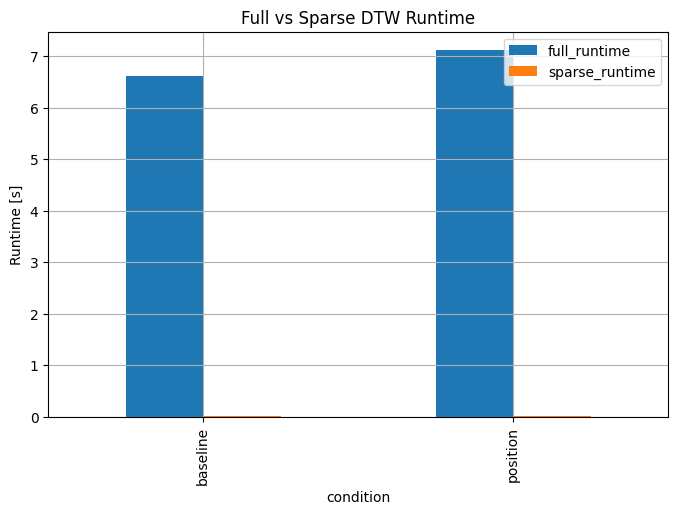

In [182]:
runtime_plot = results_df.groupby("condition")[[
    "full_runtime",
    "sparse_runtime",
]].mean()

runtime_plot.plot.bar(figsize=(8,5))

plt.ylabel("Runtime [s]")

plt.title("Full vs Sparse DTW Runtime")

plt.grid()

plt.show()

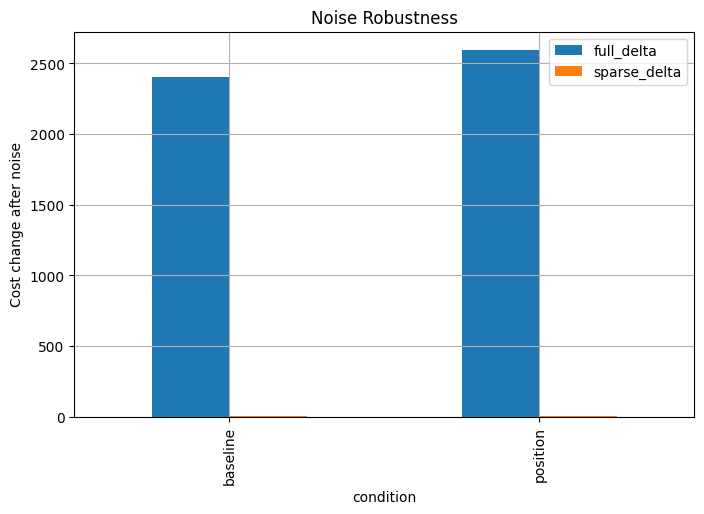

In [183]:
robustness_plot = results_df.groupby("condition")[[
    "full_delta",
    "sparse_delta",
]].mean()

robustness_plot.plot.bar(figsize=(8,5))

plt.ylabel("Cost change after noise")

plt.title("Noise Robustness")

plt.grid()

plt.show()

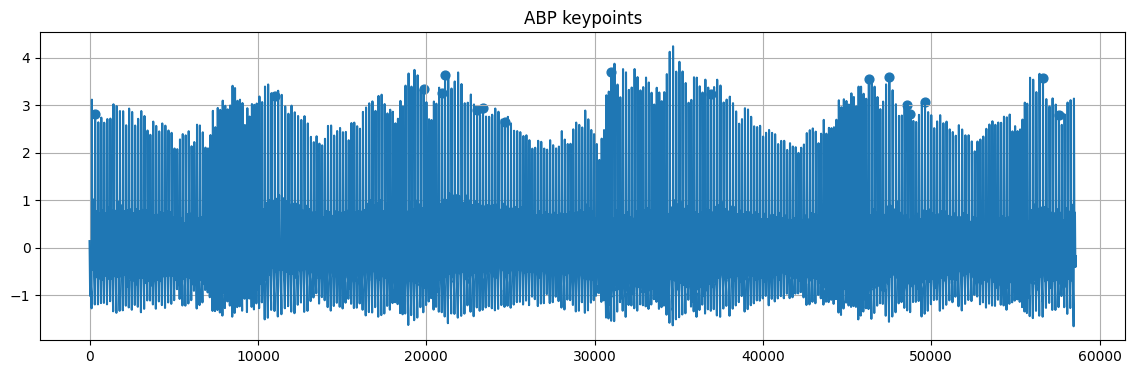

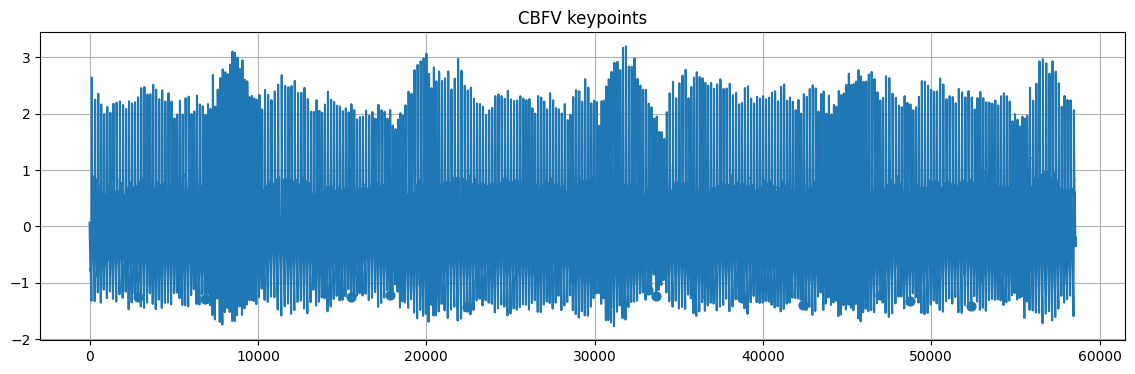

In [184]:
example_path = os.path.join(
    baseline_dir,
    os.listdir(baseline_dir)[0]
)

data = np.load(example_path)

abp = data["abp"]
cbfv = data["cbfv"]

kp_abp, desc_abp, _ = extract_sparse_representation(
    abp,
    model,
    device,
)

kp_cbfv, desc_cbfv, _ = extract_sparse_representation(
    cbfv,
    model,
    device,
)

plot_keypoints(
    abp,
    kp_abp,
    title="ABP keypoints",
)

plot_keypoints(
    cbfv,
    kp_cbfv,
    title="CBFV keypoints",
)

Trial - separation minute by minute

In [185]:
def split_into_minutes(signal, fs=200):

    minute_len = fs * 60

    segments = []
    min_len_for_conv = 3  # Minimum length required for a kernel of size 3

    for i in range(5):

        start = i * minute_len
        # Ensure 'end' does not go beyond the actual signal length
        end = min((i + 1) * minute_len, len(signal))

        current_segment = signal[start:end]

        if len(current_segment) < min_len_for_conv:
            # Pad with zeros if the segment is too short
            # The length of the padded segment will be min_len_for_conv
            padded_segment = np.pad(current_segment, (0, min_len_for_conv - len(current_segment)), 'constant', constant_values=0)
            segments.append(padded_segment)
        else:
            segments.append(current_segment)

    return segments

In [186]:
# ============================================================
# FEATURE EXTRACTION FOR ONE SEGMENT
# ============================================================

def extract_segment_features(
    abp_segment,
    cbfv_segment,
    model,
    device,
    fs=200,
):

    # ========================================================
    # sparse representations
    # ========================================================

    kp_abp, desc_abp, _ = extract_sparse_representation(
        abp_segment,
        model,
        device,
        topk=20,
        nms_window=15,
    )

    kp_cbfv, desc_cbfv, _ = extract_sparse_representation(
        cbfv_segment,
        model,
        device,
        topk=20,
        nms_window=15,
    )

    # ========================================================
    # sparse DTW
    # ========================================================

    dtw_cost, dtw_path, runtime = sparse_descriptor_dtw(
        desc_abp,
        desc_cbfv,
    )

    # ========================================================
    # delay analysis
    # ========================================================

    delays = []

    for i, j in dtw_path:

        t_abp = kp_abp[i]
        t_cbfv = kp_cbfv[j]

        delay_sec = (t_cbfv - t_abp) / fs

        delays.append(delay_sec)

    delays = np.array(delays)

    # ========================================================
    # final features
    # ========================================================

    features = {

        "dtw_cost": dtw_cost,

        "runtime": runtime,

        "mean_delay": np.mean(delays),

        "std_delay": np.std(delays),

        "num_kp_abp": len(kp_abp),

        "num_kp_cbfv": len(kp_cbfv),
    }

    return features

In [187]:
# ============================================================
# ANALYZE ONE RECORDING
# ============================================================

def analyze_recording_segments(
    path,
    condition,
    model,
    device,
):

    data = np.load(path)

    abp = data["abp"]
    cbfv = data["cbfv"]

    # split into 1-minute segments
    abp_segments = split_into_minutes(abp)
    cbfv_segments = split_into_minutes(cbfv)

    all_segments = []

    for idx in range(len(abp_segments)):

        abp_seg = abp_segments[idx]
        cbfv_seg = cbfv_segments[idx]

        features = extract_segment_features(
            abp_seg,
            cbfv_seg,
            model,
            device,
        )

        # metadata
        features["segment"] = idx
        features["condition"] = condition
        features["file"] = os.path.basename(path)

        # heuristic labels
        if condition == "baseline":
            features["state"] = "baseline"

        else:
            # first minute often transition
            if idx == 0:
                features["state"] = "transition"

            # alternating squat/stand
            elif idx % 2 == 1:
                features["state"] = "squat"

            else:
                features["state"] = "stand"

        all_segments.append(features)

    return all_segments

In [188]:
# ============================================================
# RUN FULL ANALYSIS
# ============================================================

all_results = []

In [189]:
# ============================================================
# BASELINE FILES
# ============================================================

baseline_files = sorted(os.listdir(baseline_dir))

for file in baseline_files:

    if not file.endswith(".npz"):
        continue

    path = os.path.join(
        baseline_dir,
        file,
    )

    print("Processing baseline:", file)

    results = analyze_recording_segments(
        path,
        condition="baseline",
        model=model,
        device=device,
    )

    all_results.extend(results)

Processing baseline: sample_PAC_01.npz
Processing baseline: sample_PAC_02.npz
Processing baseline: sample_PAC_03.npz
Processing baseline: sample_PAC_04.npz
Processing baseline: sample_PAC_05.npz
Processing baseline: sample_PAC_06.npz
Processing baseline: sample_PAC_07.npz
Processing baseline: sample_PAC_08.npz
Processing baseline: sample_PAC_09.npz
Processing baseline: sample_PAC_10.npz
Processing baseline: sample_PAC_11.npz
Processing baseline: sample_PAC_12.npz
Processing baseline: sample_PAC_13.npz
Processing baseline: sample_PAC_14.npz
Processing baseline: sample_PAC_15.npz
Processing baseline: sample_PAC_16.npz
Processing baseline: sample_PAC_17.npz
Processing baseline: sample_PAC_18.npz
Processing baseline: sample_PAC_19.npz
Processing baseline: sample_PAC_20.npz
Processing baseline: sample_PAC_21.npz
Processing baseline: sample_PAC_22.npz
Processing baseline: sample_PAC_23.npz
Processing baseline: sample_PAC_24.npz
Processing baseline: sample_PAC_25.npz
Processing baseline: samp

In [190]:
# ============================================================
# POSITION FILES
# ============================================================

position_files = sorted(os.listdir(position_dir))

for file in position_files:

    if not file.endswith(".npz"):
        continue

    path = os.path.join(
        position_dir,
        file,
    )

    print("Processing position:", file)

    results = analyze_recording_segments(
        path,
        condition="position",
        model=model,
        device=device,
    )

    all_results.extend(results)

Processing position: sample_0.npz
Processing position: sample_PAC_01.npz
Processing position: sample_PAC_02.npz
Processing position: sample_PAC_03.npz
Processing position: sample_PAC_04.npz
Processing position: sample_PAC_05.npz
Processing position: sample_PAC_06.npz
Processing position: sample_PAC_07.npz
Processing position: sample_PAC_08.npz
Processing position: sample_PAC_09.npz
Processing position: sample_PAC_10.npz
Processing position: sample_PAC_11.npz
Processing position: sample_PAC_12.npz
Processing position: sample_PAC_13.npz
Processing position: sample_PAC_14.npz
Processing position: sample_PAC_15.npz
Processing position: sample_PAC_16.npz
Processing position: sample_PAC_17.npz
Processing position: sample_PAC_18.npz
Processing position: sample_PAC_19.npz
Processing position: sample_PAC_20.npz
Processing position: sample_PAC_21.npz
Processing position: sample_PAC_22.npz
Processing position: sample_PAC_23.npz
Processing position: sample_PAC_24.npz
Processing position: sample_PA

In [191]:
# ============================================================
# DATAFRAME
# ============================================================

results_df = pd.DataFrame(all_results)

results_df

,dtw_cost,runtime,mean_delay,std_delay,num_kp_abp,num_kp_cbfv,segment,condition,file,state
0,15.153926,0.004026,8.371042,5.918502,20,20,0,baseline,sample_PAC_01.npz,baseline
1,17.727613,0.003872,-1.193333,6.289269,20,20,1,baseline,sample_PAC_01.npz,baseline
2,14.236681,0.003784,-7.839400,4.659236,20,20,2,baseline,sample_PAC_01.npz,baseline
3,15.530946,0.003894,-9.603846,6.462787,20,20,3,baseline,sample_PAC_01.npz,baseline
4,19.936857,0.003926,-5.603333,4.612139,20,20,4,baseline,sample_PAC_01.npz,baseline
...,...,...,...,...,...,...,...,...,...,...
470,16.527586,0.003879,7.722000,5.495506,20,20,0,position,sample_PAC_50.npz,transition
471,18.695278,0.003851,-11.584048,6.143457,20,20,1,position,sample_PAC_50.npz,squat
472,16.918284,0.003886,9.961429,4.240847,20,20,2,position,sample_PAC_50.npz,stand
473,17.623399,0.003862,-13.606739,7.463145,20,20,3,position,sample_PAC_50.npz,squat


In [192]:
# ============================================================
# FEATURES FOR CLUSTERING
# ============================================================

feature_cols = [

    "dtw_cost",

    "mean_delay",

    "std_delay",

    "num_kp_abp",

    "num_kp_cbfv",
]

# Drop rows with NaN values in the feature columns
results_df.dropna(subset=feature_cols, inplace=True)

X = results_df[feature_cols].values

In [194]:
from sklearn.preprocessing import StandardScaler

# ============================================================
# STANDARDIZATION
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [200]:
from sklearn.cluster import KMeans

# ============================================================
# KMEANS CLUSTERING
# ============================================================

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
)

clusters = kmeans.fit_predict(X_scaled)

results_df["cluster"] = clusters

In [201]:
from sklearn.decomposition import PCA

# ============================================================
# PCA VISUALIZATION
# ============================================================

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

results_df["pca1"] = X_pca[:,0]
results_df["pca2"] = X_pca[:,1]

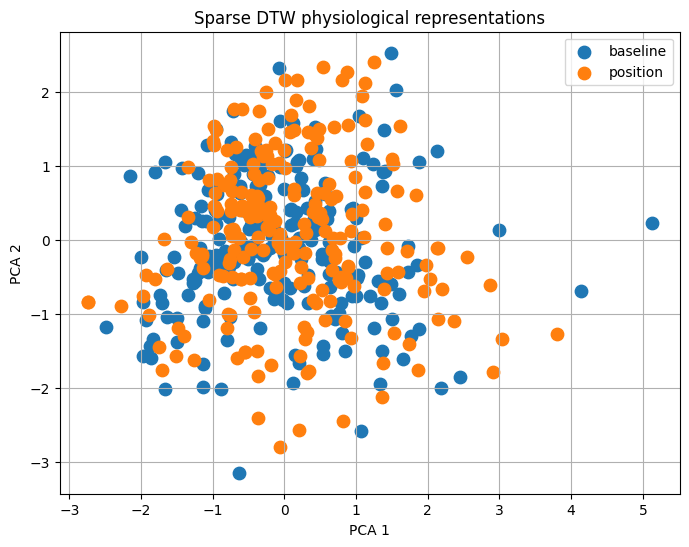

In [202]:
# ============================================================
# PLOT CLUSTERS
# ============================================================

plt.figure(figsize=(8,6))

for label in results_df["condition"].unique():

    subset = results_df[
        results_df["condition"] == label
    ]

    plt.scatter(
        subset["pca1"],
        subset["pca2"],
        label=label,
        s=80,
    )

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.title("Sparse DTW physiological representations")

plt.legend()

plt.grid()

plt.show()

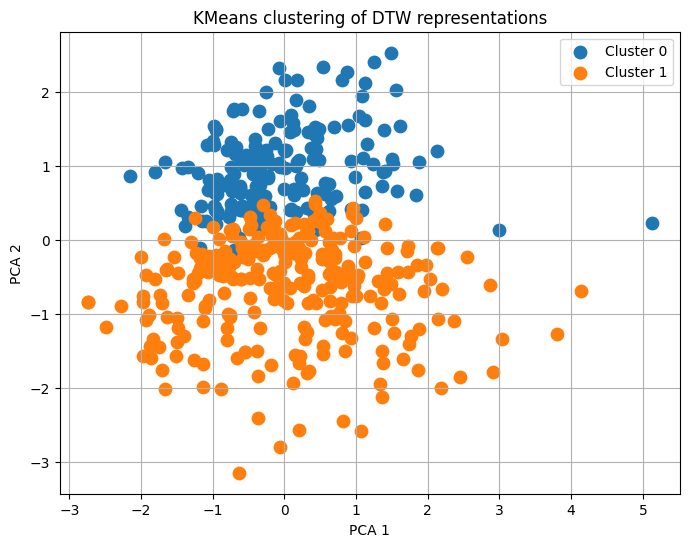

In [203]:
# ============================================================
# PLOT KMEANS CLUSTERS
# ============================================================

plt.figure(figsize=(8,6))

for cluster_id in sorted(results_df["cluster"].unique()):

    subset = results_df[
        results_df["cluster"] == cluster_id
    ]

    plt.scatter(
        subset["pca1"],
        subset["pca2"],
        label=f"Cluster {cluster_id}",
        s=80,
    )

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.title("KMeans clustering of DTW representations")

plt.legend()

plt.grid()

plt.show()

In [204]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    X_scaled,
    clusters,
)

print("Silhouette score:", score)

Silhouette score: 0.21017263935063685


In [103]:
# ============================================================
# SUMMARY TABLE
# ============================================================

summary = results_df.groupby("condition").agg({

    "dtw_cost": ["mean", "std"],

    "mean_delay": ["mean", "std"],

    "std_delay": ["mean", "std"],

    "num_kp_abp": ["mean"],

    "num_kp_cbfv": ["mean"],
})

summary

dtw_cost           mean_delay           std_delay            \
                mean       std       mean       std      mean       std   
condition                                                                 
baseline   11.212741  3.888095  -0.563755  8.038331  6.473780  2.459028   
position   10.521576  3.900340   0.219202  7.443720  6.452239  2.376129   

          num_kp_abp num_kp_cbfv  
                mean        mean  
condition                         
baseline        20.0        20.0  
position        20.0        20.0

In [104]:
# ============================================================
# OPTIONAL: STATE ANALYSIS
# ============================================================

state_summary = results_df.groupby("state").agg({

    "dtw_cost": ["mean"],

    "mean_delay": ["mean"],

    "std_delay": ["mean"],
})

state_summary

,dtw_cost,mean_delay,std_delay
,mean,mean,mean
state,,,
baseline,11.212741,-0.563755,6.473780
squat,9.562795,-1.834952,6.209889
stand,11.521900,1.798861,6.868831
transition,10.438487,1.168194,6.103756


In [110]:
checkpoints = [

    f"/content/drive/MyDrive/timepoint_weights_{SIGNAL_TO_TRAIN}_{SIGNAL_GENERATION_METHOD}_fine_tuned/model_epoch_0.pth",
    f"/content/drive/MyDrive/timepoint_weights_{SIGNAL_TO_TRAIN}_{SIGNAL_GENERATION_METHOD}_fine_tuned/model_epoch_9.pth",
    f"/content/drive/MyDrive/timepoint_weights_{SIGNAL_TO_TRAIN}_{SIGNAL_GENERATION_METHOD}_fine_tuned/model_epoch_19.pth",
    f"/content/drive/MyDrive/timepoint_weights_{SIGNAL_TO_TRAIN}_{SIGNAL_GENERATION_METHOD}_fine_tuned/model_epoch_24.pth",
]

In [111]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import pandas as pd
import numpy as np
import os

In [112]:
def evaluate_model(

    checkpoint_path,
    baseline_dir,
    position_dir,
    model_class,
    device,

):

    # ========================================================
    # LOAD MODEL
    # ========================================================

    model = model_class().to(device)

    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    model.eval()

    # ========================================================
    # RESULTS
    # ========================================================

    all_results = []

    # ========================================================
    # LOOP OVER CONDITIONS
    # ========================================================

    for condition, directory in [

        ("baseline", baseline_dir),
        ("position", position_dir),

    ]:

        files = sorted(os.listdir(directory))

        for file in files:

            if not file.endswith(".npz"):
                continue

            path = os.path.join(directory, file)

            data = np.load(path)

            abp = data["abp"]
            cbfv = data["cbfv"]

            # =================================================
            # split into 1-minute segments
            # =================================================

            abp_segments = split_into_minutes(abp)
            cbfv_segments = split_into_minutes(cbfv)

            for idx in range(len(abp_segments)):

                abp_seg = abp_segments[idx]
                cbfv_seg = cbfv_segments[idx]

                # =============================================
                # sparse representations
                # =============================================

                kp_abp, desc_abp, _ = (
                    extract_sparse_representation(
                        abp_seg,
                        model,
                        device,
                        topk=20,
                    )
                )

                kp_cbfv, desc_cbfv, _ = (
                    extract_sparse_representation(
                        cbfv_seg,
                        model,
                        device,
                        topk=20,
                    )
                )

                # =============================================
                # sparse DTW
                # =============================================

                dtw_cost, dtw_path, runtime = (
                    sparse_descriptor_dtw(
                        desc_abp,
                        desc_cbfv,
                    )
                )

                # =============================================
                # delays
                # =============================================

                delays = []

                for i, j in dtw_path:

                    delay = (
                        kp_cbfv[j] - kp_abp[i]
                    ) / 200

                    delays.append(delay)

                delays = np.array(delays)

                # =============================================
                # feature vector
                # =============================================

                result = {

                    "condition": condition,

                    "dtw_cost": dtw_cost,

                    "runtime": runtime,

                    "mean_delay": np.mean(delays),

                    "std_delay": np.std(delays),

                    "num_kp": (
                        len(kp_abp)
                        + len(kp_cbfv)
                    ) / 2,
                }

                all_results.append(result)

    # ========================================================
    # DATAFRAME
    # ========================================================

    df = pd.DataFrame(all_results)

    # ========================================================
    # FEATURE MATRIX
    # ========================================================

    feature_cols = [

        "dtw_cost",

        "mean_delay",

        "std_delay",

        "num_kp",
    ]

    # Drop rows with NaN values in the feature columns
    df.dropna(subset=feature_cols, inplace=True)

    X = df[feature_cols].values

    # ========================================================
    # SCALE
    # ========================================================

    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(X)

    # ========================================================
    # KMEANS
    # ========================================================

    kmeans = KMeans(
        n_clusters=2,
        random_state=42,
    )

    clusters = kmeans.fit_predict(X_scaled)

    # ========================================================
    # SILHOUETTE
    # ========================================================

    silhouette = silhouette_score(
        X_scaled,
        clusters,
    )

    # ========================================================
    # SUMMARY
    # ========================================================

    summary = {

        "checkpoint": checkpoint_path,

        "silhouette": silhouette,

        "avg_runtime": df["runtime"].mean(),

        "avg_kp": df["num_kp"].mean(),

        "avg_cost": df["dtw_cost"].mean(),
    }

    return summary, df

In [113]:
all_summaries = []

all_dfs = []

for checkpoint in checkpoints:

    print("Evaluating:", checkpoint)

    summary, df = evaluate_model(

        checkpoint,

        baseline_dir,
        position_dir,

        TimePointModel,

        device,
    )

    all_summaries.append(summary)

    all_dfs.append(df)

Evaluating: /content/drive/MyDrive/timepoint_weights_cbfv_lognormal_fine_tuned/model_epoch_0.pth
Evaluating: /content/drive/MyDrive/timepoint_weights_cbfv_lognormal_fine_tuned/model_epoch_9.pth
Evaluating: /content/drive/MyDrive/timepoint_weights_cbfv_lognormal_fine_tuned/model_epoch_19.pth
Evaluating: /content/drive/MyDrive/timepoint_weights_cbfv_lognormal_fine_tuned/model_epoch_24.pth


In [114]:
summary_df = pd.DataFrame(all_summaries)

summary_df

,checkpoint,silhouette,avg_runtime,avg_kp,avg_cost
0,/content/drive/MyDrive/timepoint_weights_cbfv_...,0.285191,0.003863,20.0,6.505218
1,/content/drive/MyDrive/timepoint_weights_cbfv_...,0.281629,0.003877,20.0,10.796127
2,/content/drive/MyDrive/timepoint_weights_cbfv_...,0.248154,0.003886,20.0,11.594527
3,/content/drive/MyDrive/timepoint_weights_cbfv_...,0.276126,0.003900,20.0,10.862784


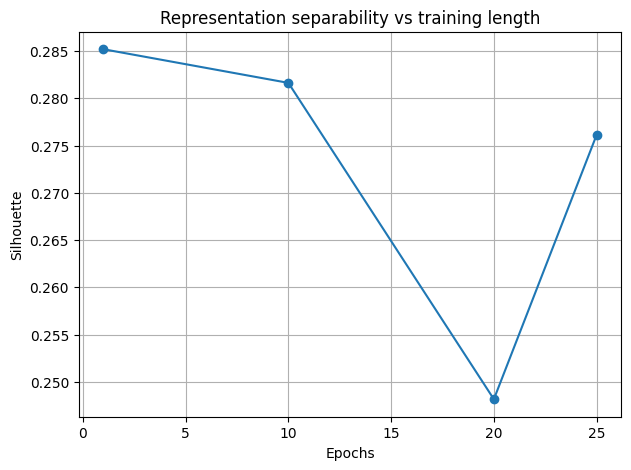

In [116]:
summary_df["epochs"] = [

    1,
    10,
    20,
    25
]

plt.figure(figsize=(7,5))

plt.plot(

    summary_df["epochs"],

    summary_df["silhouette"],

    marker="o",
)

plt.xlabel("Epochs")

plt.ylabel("Silhouette")

plt.title("Representation separability vs training length")

plt.grid()

plt.show()

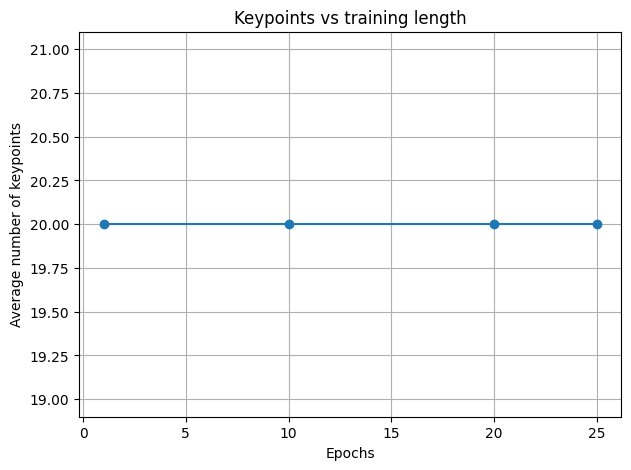

In [117]:
plt.figure(figsize=(7,5))

plt.plot(

    summary_df["epochs"],

    summary_df["avg_kp"],

    marker="o",
)

plt.xlabel("Epochs")

plt.ylabel("Average number of keypoints")

plt.title("Keypoints vs training length")

plt.grid()

plt.show()